# Truss Optimization: Single Angle vs Double Angle Comparison

This notebook visually demonstrates the optimal truss geometry generated by the `anastruct` library. It also compares the total mass (kg) required to construct the truss using the most optimal **Single Angle (L)** shapes versus the most optimal **Double Angle (2L)** shapes, checking for tension and compression slenderness.

We will focus on the structure using **18 panels** and **0.6m depth** for consistency. First, let's load our AISC Database shapes and optimization algorithms.


In [1]:
import pandas as pd
import numpy as np
import math
from anastruct import SystemElements
import matplotlib.pyplot as plt

def check_shape_si(Ag_mm2, r_min_mm, demand_tension_kn, demand_comp_kn, L_mm, Fy_mpa=250, E_mpa=200000):
    if r_min_mm == 0: return False
        
    k_l_r = L_mm / r_min_mm
    if k_l_r > 200: return False
        
    phi_t = 0.9
    Pn_t_kn = (Fy_mpa * Ag_mm2) / 1000.0
    if phi_t * Pn_t_kn < demand_tension_kn: return False
        
    Fe_mpa = (math.pi**2 * E_mpa) / (k_l_r**2)
    slenderness_limit = 4.71 * math.sqrt(E_mpa / Fy_mpa)
    
    if k_l_r <= slenderness_limit:
        Fcr_mpa = (0.658**(Fy_mpa / Fe_mpa)) * Fy_mpa
    else:
        Fcr_mpa = 0.877 * Fe_mpa
        
    phi_c = 0.9
    Pn_c_kn = (Fcr_mpa * Ag_mm2) / 1000.0
    
    if phi_c * Pn_c_kn < demand_comp_kn: return False
        
    return True

print("Loading Database...")
db = pd.read_excel('aisc-shapes-database-v160-2.xlsx', sheet_name='Database v16.0')

# Extract Double Angles (2L) with 0-spacing
db_2L = db[(db['Type'] == '2L') & (db['AISC_Manual_Label.1'].str.count('X') == 2)].copy()
# Extract Single Angles (L)
db_L = db[(db['Type'] == 'L')].copy()

def prepare_db(d):
    d['A_metric'] = pd.to_numeric(d['A.1'], errors='coerce')
    d['W_metric'] = pd.to_numeric(d['W.1'], errors='coerce')
    d['rx_metric'] = pd.to_numeric(d['rx.1'], errors='coerce')
    d['ry_metric'] = pd.to_numeric(d['ry.1'], errors='coerce')
    d['rz_metric'] = pd.to_numeric(d['rz.1'], errors='coerce')
    d['r_min_metric'] = d[['rx_metric', 'ry_metric', 'rz_metric']].min(axis=1)
    d = d.dropna(subset=['A_metric', 'r_min_metric', 'W_metric'])
    return d[d['r_min_metric'] > 0]

db_2L_clean = prepare_db(db_2L)
db_L_clean = prepare_db(db_L)

print(f"Loaded {len(db_L_clean)} Single Angles and {len(db_2L_clean)} Double Angles.")


Loading Database...


Loaded 137 Single Angles and 213 Double Angles.


In [2]:
def find_lightest(db_filtered, max_tension_kn, max_comp_kn, L_m):
    L_mm = L_m * 1000.0
    valid_shapes = []
    for idx, row in db_filtered.iterrows():
        Ag = row['A_metric']
        r_min = row['r_min_metric']
        label = row['AISC_Manual_Label.1']
        weight = row['W_metric']
        fy = 250
            
        if check_shape_si(Ag, r_min, max_tension_kn, max_comp_kn, L_mm, Fy_mpa=fy):
            valid_shapes.append({'Label': label, 'Weight': weight})
            
    if not valid_shapes: return None
    valid_shapes.sort(key=lambda x: x['Weight'])
    return valid_shapes[0]

N = 18
depth = 0.6
L_total = 18.0
dy = 1.0
dx = L_total / N
dy_per_panel = dy / N

ss = SystemElements()
for i in range(N):
    x1, y1 = i * dx, 4 + i * dy_per_panel
    x2, y2 = (i + 1) * dx, 4 + (i + 1) * dy_per_panel
    ss.add_truss_element(location=[[x1, y1], [x2, y2]])

for i in range(N):
    x1, y1 = i * dx, 4 + depth + i * dy_per_panel
    x2, y2 = (i + 1) * dx, 4 + depth + (i + 1) * dy_per_panel
    ss.add_truss_element(location=[[x1, y1], [x2, y2]])

for i in range(N + 1):
    x, y_bottom = i * dx, 4 + i * dy_per_panel
    y_top = y_bottom + depth
    ss.add_truss_element(location=[[x, y_bottom], [x, y_top]])

for i in range(N):
    x1, y_bottom = i * dx, 4 + i * dy_per_panel
    x2, y_top2 = (i + 1) * dx, 4 + depth + (i + 1) * dy_per_panel
    ss.add_truss_element(location=[[x1, y_bottom], [x2, y_top2]])

n1 = ss.find_node_id([0, 4])
n2 = ss.find_node_id([18, 5])
ss.add_support_hinged(node_id=n1)
ss.add_support_roll(node_id=n2, direction=2)

for i in range(N + 1, 2 * N + 1):
    ss.q_load(q=-2.4, element_id=i, direction='y')

ss.solve()

chord_forces = [ss.element_map[i].N_1 for i in range(1, 2 * N + 1)]
web_forces = [ss.element_map[i].N_1 for i in range(2 * N + 1, 4 * N + 2)]
chord_lengths = [ss.element_map[i].l for i in range(1, 2 * N + 1)]
web_lengths = [ss.element_map[i].l for i in range(2 * N + 1, 4 * N + 2)]

chord_max_tension = max(chord_forces) if any(f > 0 for f in chord_forces) else 0.0
chord_max_comp = abs(min(chord_forces)) if any(f < 0 for f in chord_forces) else 0.0
chord_max_length = max(chord_lengths) if chord_lengths else 0.0

web_max_tension = max(web_forces) if any(f > 0 for f in web_forces) else 0.0
web_max_comp = abs(min(web_forces)) if any(f < 0 for f in web_forces) else 0.0
web_max_length = max(web_lengths) if web_lengths else 0.0

total_chord_length = sum(chord_lengths)
total_web_length = sum(web_lengths)

def calculate_mass(db_filtered):
    chord = find_lightest(db_filtered, chord_max_tension, chord_max_comp, chord_max_length)
    web = find_lightest(db_filtered, web_max_tension, web_max_comp, web_max_length)
    
    mass = 0.0
    if chord:
        mass += chord['Weight'] * total_chord_length
    else:
        print("Warning: Missing capable chord!")
        
    if web:
        mass += web['Weight'] * total_web_length
    else:
        print("Warning: Missing capable web!")
        
    return mass

mass_L = calculate_mass(db_L_clean)
mass_2L = calculate_mass(db_2L_clean)

print("-" * 50)
print(f"Optimal Single Angle (L) Mass: {mass_L:.2f} kg")
print(f"Optimal Double Angle (2L) Mass: {mass_2L:.2f} kg")
print("-" * 50)


--------------------------------------------------
Optimal Single Angle (L) Mass: 381.73 kg
Optimal Double Angle (2L) Mass: 417.63 kg
--------------------------------------------------


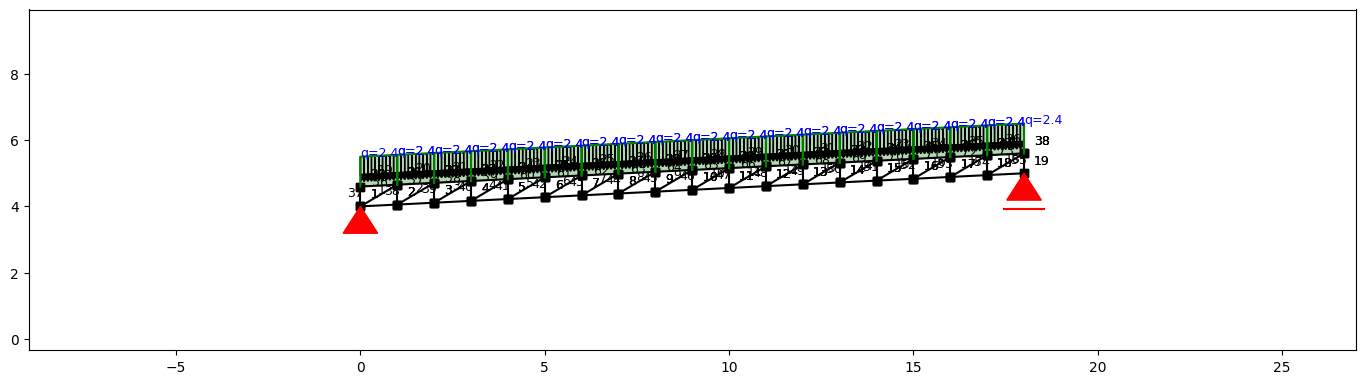

In [3]:
# Graph 1: Visualization of the Truss Structure
fig = ss.show_structure(show=True, figsize=(14, 4))


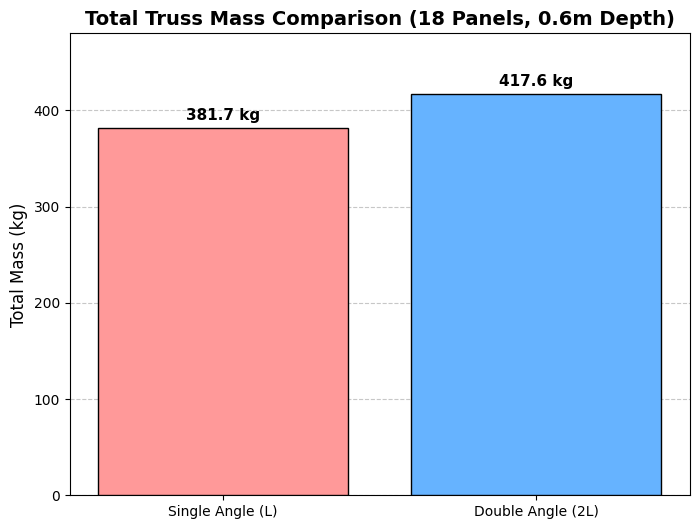

In [4]:
# Graph 2: Comparison Bar Chart
labels = ['Single Angle (L)', 'Double Angle (2L)']
masses = [mass_L, mass_2L]
colors = ['#ff9999', '#66b3ff']

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, masses, color=colors, edgecolor='black', zorder=3)
plt.title('Total Truss Mass Comparison (18 Panels, 0.6m Depth)', fontsize=14, fontweight='bold')
plt.ylabel('Total Mass (kg)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 5, f"{yval:.1f} kg", ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, max(masses) * 1.15)
plt.show()
